In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('8-fraud_detection.csv')

In [4]:
df.head()

,transaction_amount,transaction_risk_score,is_fraud
0,1.879910,-1.485035,0
1,0.377083,-2.238585,0
2,1.354312,-2.664638,0
3,-0.509843,-1.502950,0
4,0.863561,-1.906364,0


In [5]:
df['is_fraud'].unique()

array([0, 1])

In [6]:
df['is_fraud'].value_counts()

is_fraud
0    9846
1     154
Name: count, dtype: int64

In [7]:
# imbalanced dataset

In [8]:
df.isnull().sum()

transaction_amount        0
transaction_risk_score    0
is_fraud                  0
dtype: int64

In [9]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

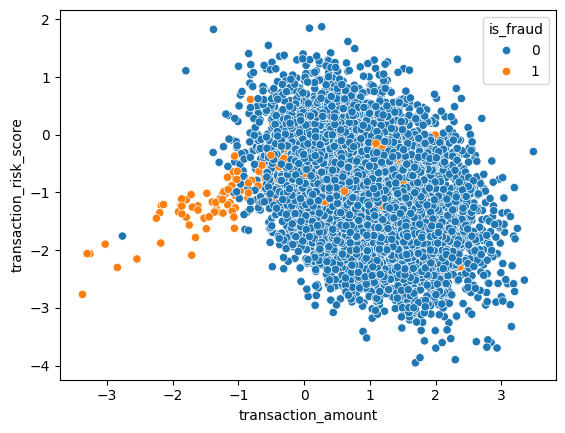

In [10]:
sns.scatterplot(x=X['transaction_amount'], y=X['transaction_risk_score'], hue=y)
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=15)

In [13]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [14]:
penalty = ["l1","l2","elasticnet"]
c_values = [100,10,1,0.1,0.01]
solver = ["newton-cg", "lbfgs", "liblinear", "sag", "saga","newton-cholesky"] 

class_weight = [{0:w, 1:y} for w in [1,10,50,100] for y in [1,10,50,100]] # diğer hyperparametertunig yapacağım zamanlarda kullanabilirim !!!!

In [15]:
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [16]:
params = dict(penalty=penalty, C=c_values, solver=solver, class_weight=class_weight)

In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [18]:
cv = StratifiedKFold()

In [19]:
grid = GridSearchCV(estimator=model, param_grid=params, scoring="accuracy", cv=cv)

In [20]:
import warnings
warnings.filterwarnings("ignore")

In [21]:
grid.fit(X_train,y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [22]:
y_pred = grid.predict(X_test)

In [23]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(3000,))

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
print("score: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion matrix: \n", confusion_matrix(y_test, y_pred))

score:  0.9893333333333333
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2951
           1       0.87      0.41      0.56        49

    accuracy                           0.99      3000
   macro avg       0.93      0.70      0.78      3000
weighted avg       0.99      0.99      0.99      3000

Confusion matrix: 
 [[2948    3]
 [  29   20]]


In [26]:
grid.best_params_

{'C': 0.01,
 'class_weight': {0: 10, 1: 50},
 'penalty': 'l2',
 'solver': 'newton-cg'}

In [27]:
# [[TN, FP],  
# [FN, TP]]

In [28]:
# roc , auc

The ROC Curve is a graphical representation of a classification model’s performance across different threshold values. It plots the True Positive Rate (Recall) on the Y-axis against the False Positive Rate (1 - Specificity) on the X-axis. • A model that perfectly distinguishes between classes has a curve that reaches the top-left corner. • The closer the curve is to the top-left, the better the model. • The area under the ROC curve (AUC) quantifies this performance: • AUC = 1 → perfect classifier • AUC = 0.5 → random guessing

ROC is especially useful for imbalanced datasets, as it evaluates the model independent of class distribution or threshold.

ROC Eğrisi, bir sınıflandırma modelinin farklı eşik değerleri (threshold) boyunca performansını gösteren grafiksel bir temsilidir.

Y eksenine True Positive Rate (Recall / Duyarlılık),

X eksenine ise False Positive Rate (1 - Specificity / Yanlış Pozitif Oranı) çizilir.

Eğer model sınıfları mükemmel şekilde ayırabiliyorsa, eğri grafiğin sol üst köşesine kadar çıkar.

Eğri sol üste ne kadar yakınsa, model o kadar iyidir.

ROC eğrisinin altında kalan alan (AUC) bu performansı sayısal olarak ölçer:

AUC = 1 → Mükemmel sınıflandırıcı

AUC = 0.5 → Rastgele tahmin yapan model

Ayrıca ROC, özellikle dengesiz (imbalanced) veri setlerinde faydalıdır çünkü modeli sınıf dağılımından veya eşik değerinden bağımsız olarak değerlendirir.

In [29]:
model_prob = grid.predict_proba(X_test) # Olasılıkları bu şekilde görebiliriz.

In [30]:
model_prob 

array([[0.99541523, 0.00458477],
       [0.85804185, 0.14195815],
       [0.95194979, 0.04805021],
       ...,
       [0.96100575, 0.03899425],
       [0.98625237, 0.01374763],
       [0.76576844, 0.23423156]], shape=(3000, 2))

In [31]:
model_prob = model_prob[:,1] # sağ  tarafı yani pozitif sınıf için olan olasılıkları (fraud) alıyoruz.

In [32]:
model_prob

array([0.00458477, 0.14195815, 0.04805021, ..., 0.03899425, 0.01374763,
       0.23423156], shape=(3000,))

In [33]:
from sklearn.metrics import roc_curve , roc_auc_score # auc score 1 e ne kadar yakında modelimiz o kadar iyi çalışıyor demektir!

In [34]:
model_auc = roc_auc_score(y_test, model_prob)

In [35]:
model_auc

0.779196260001798

In [36]:
model_fpr, model_tpr, thresholds = roc_curve(y_test, model_prob) # 3 tane dizi dönüyor bunlardan 1-> false positive rate, 2-> true positive rate, 3-> threshold

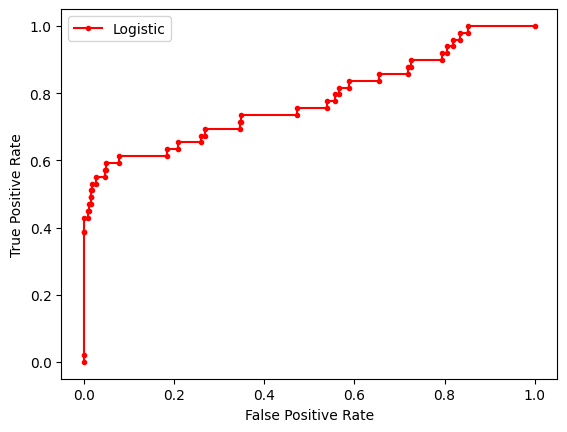

In [37]:
plt.plot(model_fpr, model_tpr, marker=".", label="Logistic", color="r")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

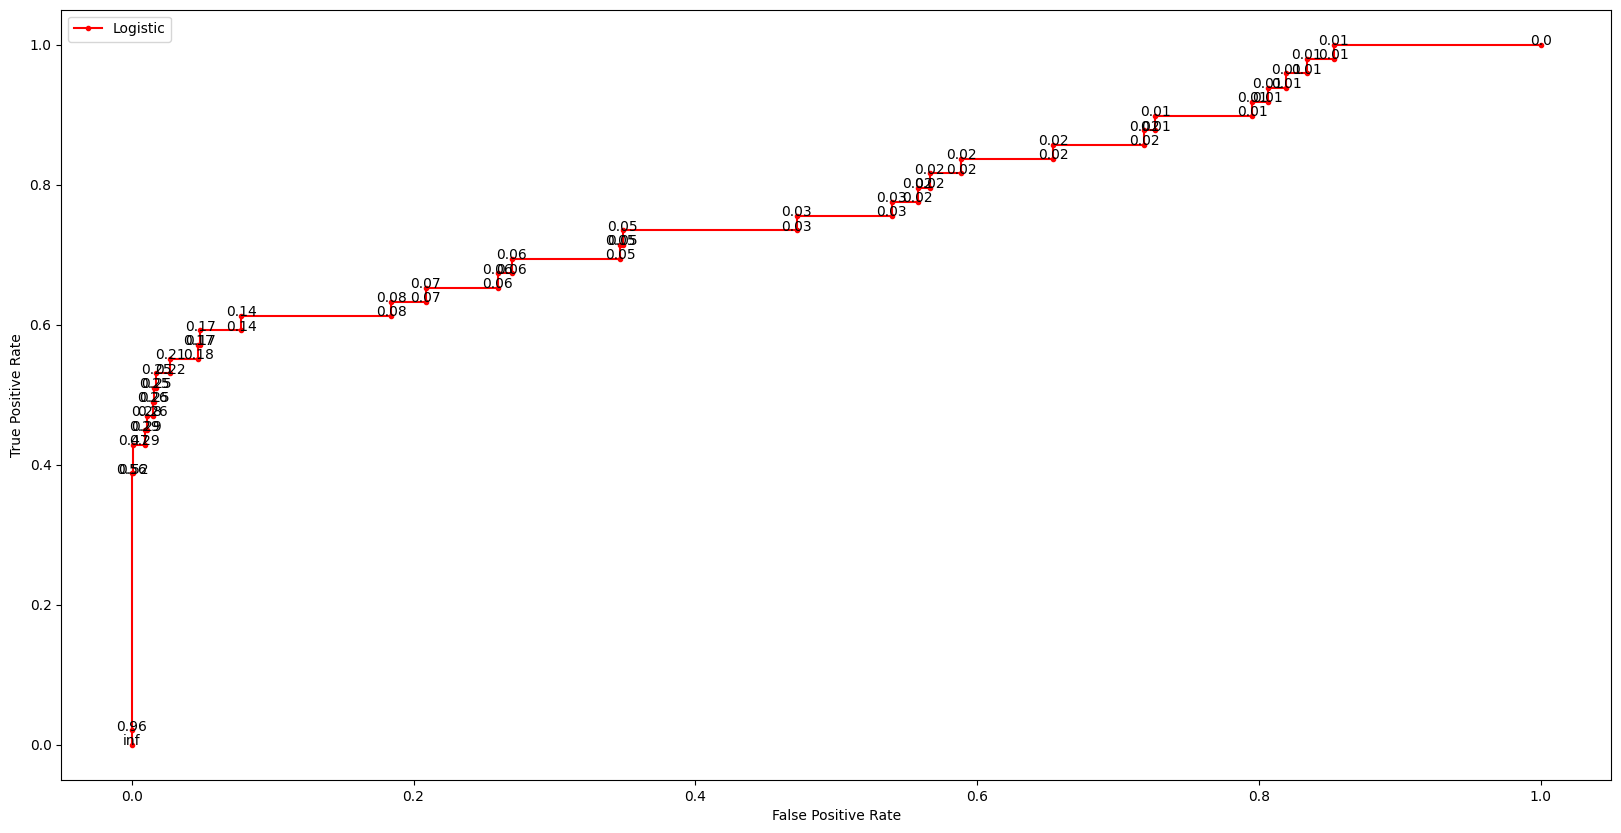

In [38]:
fig, ax = plt.subplots(figsize = (20,10))

ax.plot(model_fpr, model_tpr, marker=".", label="Logistic", color="r")

for fpr , tpr, thresh in zip(model_fpr,model_tpr, thresholds):
    ax.annotate(f"{np.round(thresh, 2)}", (fpr, tpr), ha = "center")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

In [39]:
custom_threshold = 0.3

y_pred_custom = (model_prob >= custom_threshold).astype(int)

print(confusion_matrix(y_pred_custom, y_test))
print(classification_report(y_pred_custom,y_test)) # (y_test, y_pred) --> olması gereken bu şekilde her zaman !!

[[2928   28]
 [  23   21]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2956
           1       0.43      0.48      0.45        44

    accuracy                           0.98      3000
   macro avg       0.71      0.73      0.72      3000
weighted avg       0.98      0.98      0.98      3000



In [40]:
y_pred_custom

array([0, 0, 0, ..., 0, 0, 0], shape=(3000,))

ROC AUC = 0.9 → Model çok iyi görünüyor… ama!

Her zaman “işe yarar” anlamına gelmez. Neden?

Dengesiz veri seti (imbalanced data) problemi

Diyelim ki dataset %99 negatif, %1 pozitif.

Model negatifleri iyi ayırıyorsa AUC çok yüksek çıkabilir.

Ama aslında pozitifleri yakalayamıyordur → işin biter.
👉 Bu durumda ROC seni kandırabilir.

İşin doğası önemli (cost-sensitive problem)

Fraud detection’da yanlış negatif (kaçan sahtecilik) çok pahalıdır.

Kanser testinde yanlış negatif öldürür.

Yani sadece AUC’ye bakıp “tamam bu model süper” diyemezsin, Precision, Recall, F1 de bakman lazım.

Threshold seçimi yok sayılır

AUC, tüm threshold’ları özetler.

Ama gerçek hayatta sen tek bir threshold seçmek zorundasın (mesela 0.5).

O threshold’taki performans kötü olabilir, AUC yüksek olsa bile.

# 🔑 Özet 

ROC Eğrisi → Modelin genel ayırt etme gücü.

PR Eğrisi → Modelin pozitif sınıfı ne kadar iyi yakaladığı.

👉 Eğer dataset dengeli = ROC daha kullanışlı.
👉 Eğer dataset dengesiz (imbalanced) = PR daha kritik.